In [1]:
# Install required modules
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [3]:
# Advanced DDoS Backend ML Model

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# =========================
# 1. Load Dataset
# =========================

DATASET_PATH = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df = pd.read_csv(DATASET_PATH)
df.columns = df.columns.str.strip()

print("Dataset Loaded:", df.shape)
df.head()

Dataset Loaded: (225745, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# =========================
# 2. Preprocessing
# =========================

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.drop_duplicates(inplace=True)

if "Label" not in df.columns:
    raise ValueError("Label column not found")

df["Label"] = df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

df.dropna(subset=["Label"], inplace=True)
df["Label"] = df["Label"].astype(int)

X = df.drop("Label", axis=1)
X = X.select_dtypes(include=[np.number])

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
X = X.fillna(0)

y = df["Label"]

print("Final feature shape:", X.shape)
print("Class count:")
print(y.value_counts())

Final feature shape: (225743, 80)
Class count:
Label
1    128027
0     97716
Name: count, dtype: int64


In [5]:
# =========================
# 3. Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.75,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 169307
Testing samples: 56436


In [6]:
# =========================
# 4. Accurate Fast Ensemble Model
# =========================

rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=25,
    min_samples_split=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

et_model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=25,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

hgb_model = HistGradientBoostingClassifier(
    max_iter=120,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

model = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("et", et_model),
        ("hgb", hgb_model)
    ],
    voting="soft",
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Training completed")

Training completed


In [7]:
# =========================
# 5. Evaluation
# =========================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation")
print("-" * 40)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "DDoS"]
))

Model Evaluation
----------------------------------------
Accuracy : 0.9999468424409951
Precision: 0.9999375156210947
Recall   : 0.9999687568344424
F1 Score : 0.9999531359837538

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     24429
        DDoS       1.00      1.00      1.00     32007

    accuracy                           1.00     56436
   macro avg       1.00      1.00      1.00     56436
weighted avg       1.00      1.00      1.00     56436



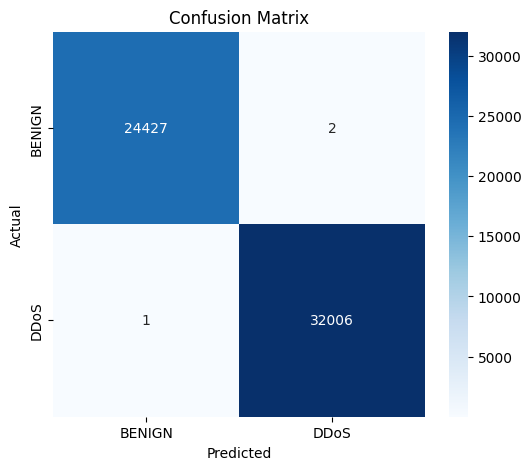

In [8]:
# =========================
# 6. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DDoS"],
    yticklabels=["BENIGN", "DDoS"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

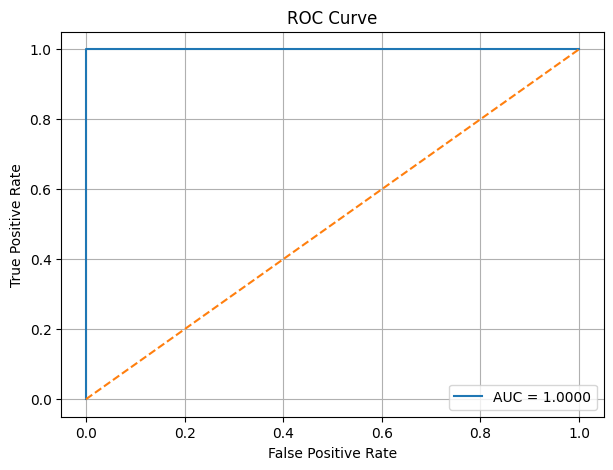

In [9]:
# =========================
# 7. ROC Curve
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

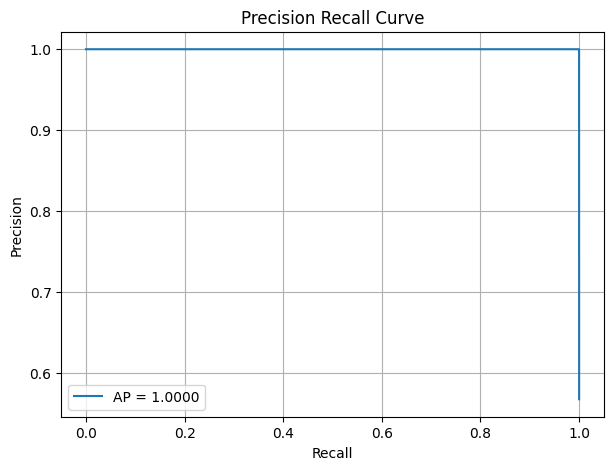

In [10]:
# =========================
# 8. Precision Recall Curve
# =========================

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"AP = {average_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

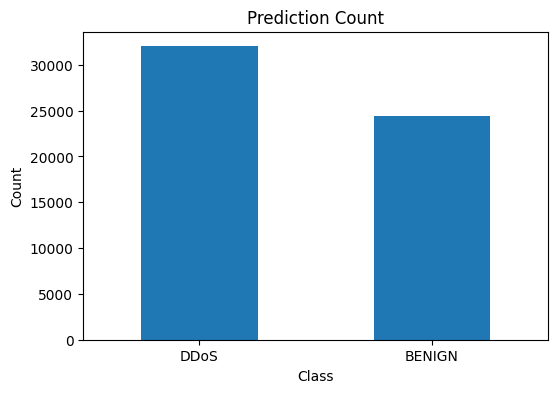

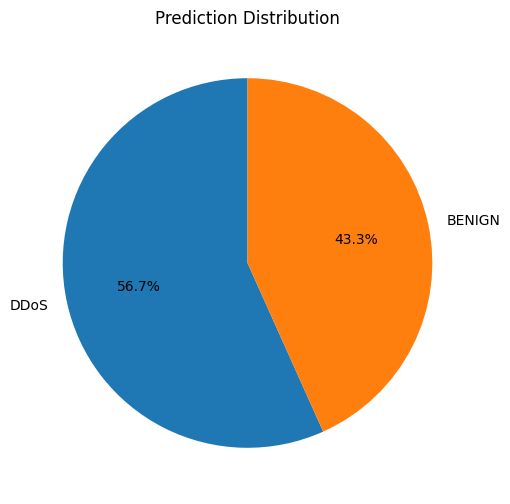

In [11]:
# =========================
# 9. Prediction Distribution
# =========================

pred_labels = pd.Series(y_pred).map({
    0: "BENIGN",
    1: "DDoS"
})

counts = pred_labels.value_counts()

plt.figure(figsize=(6, 4))
counts.plot(kind="bar")
plt.title("Prediction Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6, 6))
counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Prediction Distribution")
plt.show()

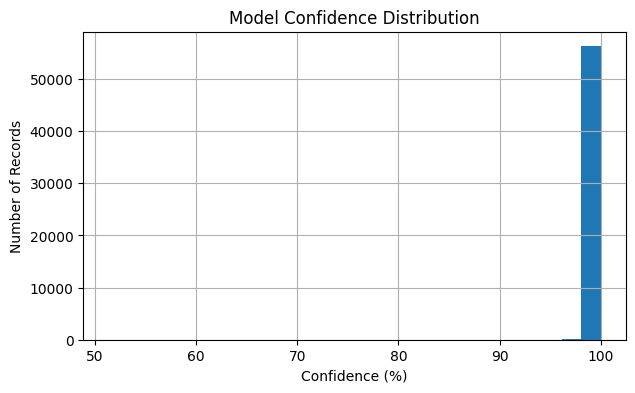

In [12]:
# =========================
# 10. Confidence Distribution
# =========================

confidence = np.maximum(y_prob, 1 - y_prob) * 100

plt.figure(figsize=(7, 4))
plt.hist(confidence, bins=25)
plt.xlabel("Confidence (%)")
plt.ylabel("Number of Records")
plt.title("Model Confidence Distribution")
plt.grid(True)
plt.show()

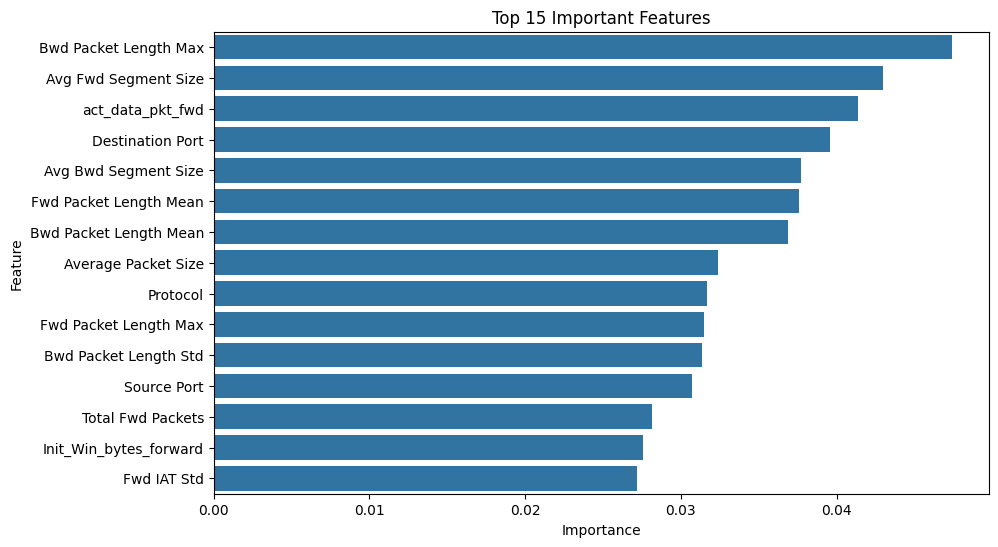

,Feature,Importance
12,Bwd Packet Length Max,0.047388
55,Avg Fwd Segment Size,0.042972
70,act_data_pkt_fwd,0.041384
1,Destination Port,0.039543
56,Avg Bwd Segment Size,0.037738
10,Fwd Packet Length Mean,0.037607
14,Bwd Packet Length Mean,0.036847
54,Average Packet Size,0.032398
2,Protocol,0.031656
8,Fwd Packet Length Max,0.031482


In [13]:
# =========================
# 11. Feature Importance
# =========================

# Average feature importance from RF and ExtraTrees
rf_importance = model.named_estimators_["rf"].feature_importances_
et_importance = model.named_estimators_["et"].feature_importances_

avg_importance = (rf_importance + et_importance) / 2

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": avg_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features")
plt.show()

feature_importance_df.head(20)

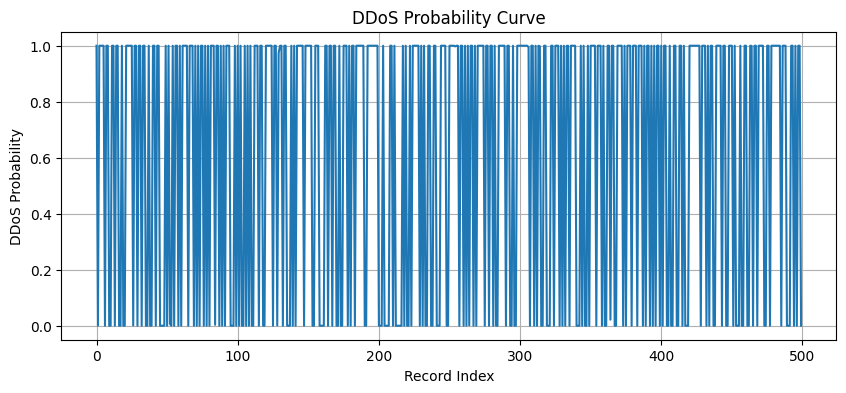

In [14]:
# =========================
# 12. Class Probability Curve
# =========================

sample_size = min(500, len(y_prob))

plt.figure(figsize=(10, 4))
plt.plot(y_prob[:sample_size])
plt.xlabel("Record Index")
plt.ylabel("DDoS Probability")
plt.title("DDoS Probability Curve")
plt.grid(True)
plt.show()

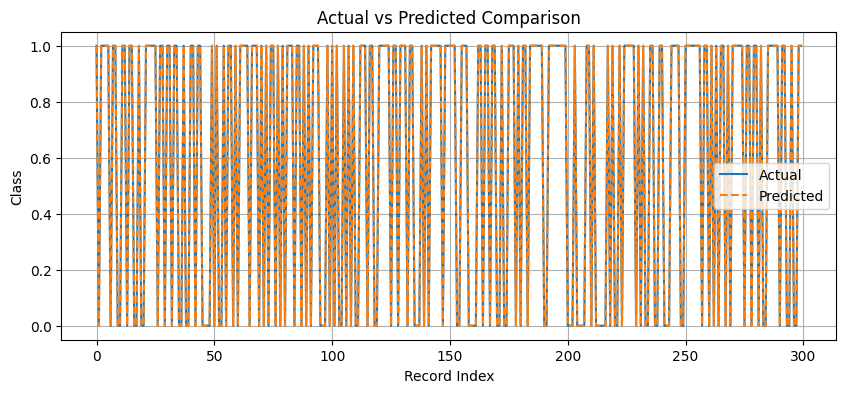

In [15]:
# =========================
# 13. Actual vs Predicted Graph
# =========================

sample_size = min(300, len(y_test))

plt.figure(figsize=(10, 4))
plt.plot(np.array(y_test[:sample_size]), label="Actual")
plt.plot(y_pred[:sample_size], label="Predicted", linestyle="--")
plt.xlabel("Record Index")
plt.ylabel("Class")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.grid(True)
plt.show()

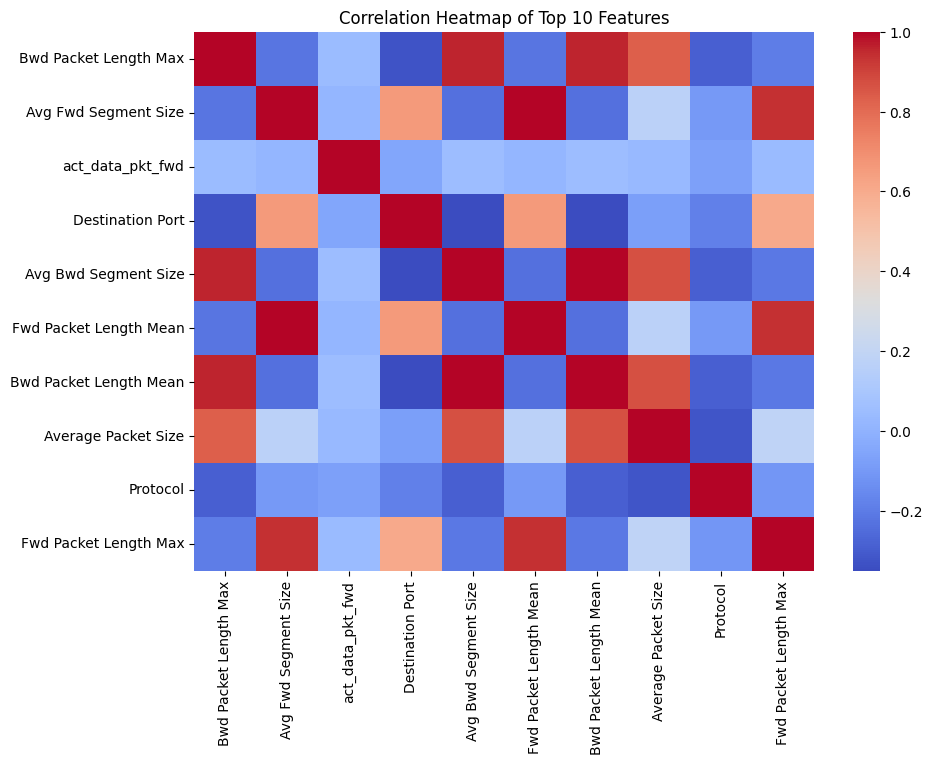

In [16]:
# =========================
# 14. Correlation Heatmap
# =========================

top_features = feature_importance_df.head(10)["Feature"].tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    X[top_features].corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap of Top 10 Features")
plt.show()

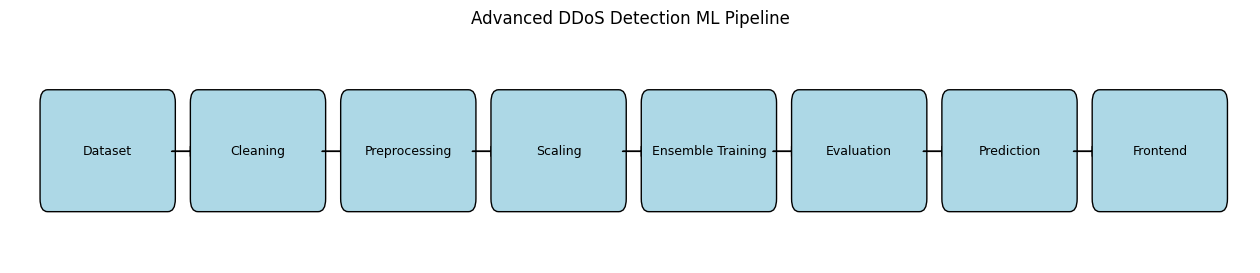

In [17]:
# =========================
# 15. Workflow Diagram
# =========================

import matplotlib.patches as patches

steps = [
    "Dataset",
    "Cleaning",
    "Preprocessing",
    "Scaling",
    "Ensemble Training",
    "Evaluation",
    "Prediction",
    "Frontend"
]

plt.figure(figsize=(16, 3))
ax = plt.gca()
ax.axis("off")

for i, step in enumerate(steps):
    x = i * 2

    box = patches.FancyBboxPatch(
        (x, 0),
        1.6,
        0.75,
        boxstyle="round,pad=0.1",
        edgecolor="black",
        facecolor="lightblue"
    )

    ax.add_patch(box)

    ax.text(
        x + 0.8,
        0.37,
        step,
        ha="center",
        va="center",
        fontsize=9
    )

    if i < len(steps) - 1:
        ax.arrow(
            x + 1.65,
            0.37,
            0.25,
            0,
            head_width=0.08,
            head_length=0.1,
            fc="black",
            ec="black"
        )

plt.xlim(-0.5, len(steps) * 2)
plt.ylim(-0.5, 1.3)
plt.title("Advanced DDoS Detection ML Pipeline")
plt.show()

In [18]:
# =========================
# 16. Save Backend Files for Frontend
# =========================

os.makedirs("model", exist_ok=True)

metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc,
    "average_precision": average_precision,
    "train_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "total_features": int(X.shape[1])
}

joblib.dump(model, "model/model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(list(X.columns), "model/features.pkl")
joblib.dump(metrics, "model/metrics.pkl")

feature_importance_df.to_csv("model/feature_importance.csv", index=False)

print("Saved backend files:")
print("model/model.pkl")
print("model/scaler.pkl")
print("model/features.pkl")
print("model/metrics.pkl")
print("model/feature_importance.csv")

Saved backend files:
model/model.pkl
model/scaler.pkl
model/features.pkl
model/metrics.pkl
model/feature_importance.csv


In [19]:
# =========================
# 17. Download Backend Files
# =========================

!zip -r ddos_backend_model_files.zip model

from google.colab import files
files.download("ddos_backend_model_files.zip")

  adding: model/ (stored 0%)
  adding: model/model.pkl (deflated 68%)
  adding: model/metrics.pkl (deflated 15%)
  adding: model/feature_importance.csv (deflated 56%)
  adding: model/scaler.pkl (deflated 68%)
  adding: model/features.pkl (deflated 64%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
%%writefile app.py
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st

st.set_page_config(
    page_title="Animated DDoS Detection Dashboard",
    page_icon="🛡️",
    layout="wide"
)

# ==========================
# ANIMATED CSS
# ==========================

st.markdown("""
<style>
.stApp {
    background: radial-gradient(circle at top left, #1e3a8a 0%, #020617 35%, #0f172a 100%);
    color: #f8fafc;
}

[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #020617, #0f172a, #111827);
}

.hero {
    padding: 38px;
    border-radius: 30px;
    background: linear-gradient(135deg, rgba(14,165,233,.28), rgba(37,99,235,.18));
    border: 1px solid rgba(56,189,248,.4);
    box-shadow: 0 0 35px rgba(56,189,248,.25);
    animation: slideFade .9s ease-in-out;
}

.hero h1 {
    text-align: center;
    font-size: 50px;
    color: #38bdf8;
    font-weight: 900;
}

.hero p {
    text-align: center;
    font-size: 18px;
    color: #cbd5e1;
}

.card {
    background: rgba(15, 23, 42, .92);
    border: 1px solid rgba(148, 163, 184, .25);
    border-radius: 24px;
    padding: 24px;
    margin-bottom: 18px;
    box-shadow: 0 10px 30px rgba(0,0,0,.35);
    animation: floatIn .8s ease-in-out;
    transition: transform .35s ease, box-shadow .35s ease;
}

.card:hover {
    transform: translateY(-7px) scale(1.01);
    box-shadow: 0 0 35px rgba(56,189,248,.28);
}

.safe {
    background: linear-gradient(135deg, #064e3b, #047857);
    border-left: 7px solid #22c55e;
}

.danger {
    background: linear-gradient(135deg, #7f1d1d, #991b1b);
    border-left: 7px solid #ef4444;
}

.warn {
    background: linear-gradient(135deg, #713f12, #92400e);
    border-left: 7px solid #f59e0b;
}

.info {
    background: linear-gradient(135deg, #1e3a8a, #1d4ed8);
    border-left: 7px solid #38bdf8;
}

.metric-num {
    font-size: 40px;
    font-weight: 900;
    color: #38bdf8;
}

.small-label {
    color: #cbd5e1;
    font-size: 15px;
}

.pulse {
    animation: pulseGlow 1.8s infinite;
}

.carousel {
    display: flex;
    overflow-x: auto;
    gap: 18px;
    scroll-snap-type: x mandatory;
    padding: 18px 0;
}

.carousel img {
    min-width: 430px;
    height: 235px;
    object-fit: cover;
    border-radius: 24px;
    scroll-snap-align: center;
    border: 1px solid rgba(56,189,248,.35);
    box-shadow: 0 12px 30px rgba(0,0,0,.4);
    transition: transform .35s ease;
}

.carousel img:hover {
    transform: scale(1.04);
}

.carousel::-webkit-scrollbar {
    height: 8px;
}

.carousel::-webkit-scrollbar-thumb {
    background: #38bdf8;
    border-radius: 12px;
}

.stButton > button {
    background: linear-gradient(90deg, #0284c7, #2563eb);
    color: white;
    border-radius: 16px;
    padding: 13px 34px;
    font-weight: 900;
    border: none;
    box-shadow: 0 0 18px rgba(37,99,235,.35);
    transition: .3s;
}

.stButton > button:hover {
    background: linear-gradient(90deg, #0ea5e9, #1d4ed8);
    transform: scale(1.04);
    color: white;
}

.badge {
    display: inline-block;
    padding: 6px 14px;
    border-radius: 20px;
    color: white;
    font-weight: 700;
}

.low { background: #16a34a; }
.medium { background: #ca8a04; }
.high { background: #ea580c; }
.critical { background: #dc2626; }

@keyframes slideFade {
    from { opacity: 0; transform: translateY(-25px); }
    to { opacity: 1; transform: translateY(0); }
}

@keyframes floatIn {
    from { opacity: 0; transform: translateY(25px); }
    to { opacity: 1; transform: translateY(0); }
}

@keyframes pulseGlow {
    0% { box-shadow: 0 0 8px rgba(56,189,248,.25); }
    50% { box-shadow: 0 0 30px rgba(56,189,248,.55); }
    100% { box-shadow: 0 0 8px rgba(56,189,248,.25); }
}
</style>
""", unsafe_allow_html=True)

# ==========================
# BACKEND FILES
# ==========================

MODEL_PATH = "model/model.pkl"
SCALER_PATH = "model/scaler.pkl"
FEATURES_PATH = "model/features.pkl"
METRICS_PATH = "model/metrics.pkl"
FEATURE_IMPORTANCE_PATH = "model/feature_importance.csv"

for path in [MODEL_PATH, SCALER_PATH, FEATURES_PATH]:
    if not os.path.exists(path):
        st.error(f"Missing backend file: {path}")
        st.stop()

@st.cache_resource
def load_backend():
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    features = joblib.load(FEATURES_PATH)
    metrics = joblib.load(METRICS_PATH) if os.path.exists(METRICS_PATH) else None
    feature_importance = pd.read_csv(FEATURE_IMPORTANCE_PATH) if os.path.exists(FEATURE_IMPORTANCE_PATH) else None
    return model, scaler, features, metrics, feature_importance

model, scaler, features, metrics, feature_importance = load_backend()

# ==========================
# IMAGES
# ==========================

IMAGES = [
    "https://images.unsplash.com/photo-1550751827-4bd374c3f58b",
    "https://images.unsplash.com/photo-1558494949-ef010cbdcc31",
    "https://images.unsplash.com/photo-1516321318423-f06f85e504b3",
    "https://images.unsplash.com/photo-1526374965328-7f61d4dc18c5",
    "https://images.unsplash.com/photo-1551288049-bebda4e38f71"
]

def show_hero(title, subtitle):
    st.markdown(f"""
    <div class="hero pulse">
        <h1>{title}</h1>
        <p>{subtitle}</p>
    </div>
    """, unsafe_allow_html=True)

    html = '<div class="carousel">'
    for img in IMAGES:
        html += f'<img src="{img}">'
    html += '</div>'
    st.markdown(html, unsafe_allow_html=True)

def metric_card(title, value, css="card"):
    st.markdown(f"""
    <div class="{css}">
        <div class="small-label">{title}</div>
        <div class="metric-num">{value}</div>
    </div>
    """, unsafe_allow_html=True)

# ==========================
# SIDEBAR
# ==========================

st.sidebar.image("https://cdn-icons-png.flaticon.com/512/2092/2092663.png", width=120)
st.sidebar.title("🛡️ Cyber AI")

page = st.sidebar.radio(
    "Navigation",
    [
        "Dashboard",
        "Prediction Lab",
        "Traffic Insights",
        "Model & Features",
        "Project Info"
    ]
)

st.sidebar.success("Backend active")
st.sidebar.write("Feature count:", len(features))

# ==========================
# DASHBOARD
# ==========================

if page == "Dashboard":

    show_hero(
        "🛡️ Animated DDoS Detection Dashboard",
        "Smart ML-powered cybersecurity detection with dynamic visual analytics"
    )

    c1, c2, c3 = st.columns(3)

    with c1:
        metric_card("Backend Status", "Active", "card info")
    with c2:
        metric_card("Total Features", len(features), "card")
    with c3:
        acc = metrics.get("accuracy", 0) * 100 if metrics else 0
        metric_card("Model Accuracy", f"{acc:.2f}%", "card")

    st.markdown("""
    <div class="card info">
        <h3>✨ What is new?</h3>
        <p>
        Fewer navigation options, animated dashboard cards, swipe image carousel,
        prediction lab, traffic insights, model analytics, risk-level detection,
        probability curves, confidence visualization, and downloadable reports.
        </p>
    </div>
    """, unsafe_allow_html=True)

# ==========================
# PREDICTION LAB
# ==========================

elif page == "Prediction Lab":

    show_hero(
        "📤 Prediction Lab",
        "Upload traffic CSV, run ML prediction, and view real-time visual analysis"
    )

    uploaded_file = st.file_uploader("Upload test CSV file", type=["csv"])

    if uploaded_file is not None:

        df = pd.read_csv(uploaded_file)
        df.columns = df.columns.str.strip()

        st.subheader("Dataset Preview")
        st.dataframe(df.head())

        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Rows", df.shape[0])
        c2.metric("Columns", df.shape[1])
        c3.metric("Missing", int(df.isnull().sum().sum()))
        c4.metric("Features Required", len(features))

        missing_cols = [col for col in features if col not in df.columns]
        if missing_cols:
            st.error("Uploaded CSV is missing required columns.")
            st.write(missing_cols[:50])
            st.stop()

        X = df[features].replace([np.inf, -np.inf], np.nan)
        X = X.fillna(X.median(numeric_only=True)).fillna(0)
        X_scaled = scaler.transform(X)

        if st.button("🚀 Run Prediction"):

            with st.spinner("Analyzing traffic packets..."):
                bar = st.progress(0)
                for i in range(100):
                    time.sleep(0.004)
                    bar.progress(i + 1)

                predictions = model.predict(X_scaled)

                if hasattr(model, "predict_proba"):
                    probs = model.predict_proba(X_scaled)
                    benign_prob = probs[:, 0] * 100
                    ddos_prob = probs[:, 1] * 100
                    confidence = np.max(probs, axis=1) * 100
                else:
                    benign_prob = np.zeros(len(predictions))
                    ddos_prob = np.zeros(len(predictions))
                    confidence = np.zeros(len(predictions))

            labels = pd.Series(predictions).map({0: "BENIGN", 1: "DDoS"}).fillna(pd.Series(predictions).astype(str))

            result_df = df.copy()
            result_df["Prediction"] = labels
            result_df["BENIGN Probability (%)"] = np.round(benign_prob, 2)
            result_df["DDoS Probability (%)"] = np.round(ddos_prob, 2)
            result_df["Confidence (%)"] = np.round(confidence, 2)
            result_df["Risk Level"] = pd.cut(
                result_df["DDoS Probability (%)"],
                bins=[-1, 30, 60, 85, 100],
                labels=["Low", "Medium", "High", "Critical"]
            )

            st.session_state["result_df"] = result_df
            st.session_state["processed_X"] = X

            benign_df = result_df[result_df["Prediction"] == "BENIGN"]
            ddos_df = result_df[result_df["Prediction"] == "DDoS"]

            st.success("Prediction completed")

            a, b, c, d = st.columns(4)
            with a:
                metric_card("Total Records", len(result_df), "card")
            with b:
                metric_card("BENIGN", len(benign_df), "card safe")
            with c:
                metric_card("DDoS", len(ddos_df), "card danger")
            with d:
                metric_card("Avg Confidence", f"{np.mean(confidence):.2f}%", "card warn")

            tabs = st.tabs(["📋 Results", "📊 Graphs", "📈 Curves", "⚠️ Risk", "⬇️ Export"])

            with tabs[0]:
                st.dataframe(
                    result_df[
                        [
                            "Prediction",
                            "Risk Level",
                            "Confidence (%)",
                            "BENIGN Probability (%)",
                            "DDoS Probability (%)"
                        ]
                    ].head(1000)
                )

            with tabs[1]:
                counts = labels.value_counts()
                col1, col2 = st.columns(2)

                with col1:
                    fig, ax = plt.subplots(figsize=(6, 4))
                    ax.bar(counts.index, counts.values)
                    ax.set_title("Prediction Count")
                    ax.set_xlabel("Class")
                    ax.set_ylabel("Records")
                    st.pyplot(fig)

                with col2:
                    fig, ax = plt.subplots(figsize=(6, 4))
                    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
                    ax.set_title("Prediction Distribution")
                    st.pyplot(fig)

                fig, ax = plt.subplots(figsize=(8, 4))
                ax.hist(result_df["Confidence (%)"], bins=25)
                ax.set_title("Confidence Distribution")
                ax.set_xlabel("Confidence (%)")
                ax.set_ylabel("Records")
                ax.grid(True)
                st.pyplot(fig)

            with tabs[2]:
                sample = min(900, len(result_df))

                fig, ax = plt.subplots(figsize=(11, 4))
                ax.plot(result_df.index[:sample], result_df["BENIGN Probability (%)"][:sample], label="BENIGN")
                ax.plot(result_df.index[:sample], result_df["DDoS Probability (%)"][:sample], label="DDoS")
                ax.set_title("BENIGN vs DDoS Probability Curve")
                ax.set_xlabel("Record Index")
                ax.set_ylabel("Probability (%)")
                ax.legend()
                ax.grid(True)
                st.pyplot(fig)

                fig, ax = plt.subplots(figsize=(11, 4))
                ax.plot(result_df.index[:sample], result_df["Confidence (%)"][:sample])
                ax.set_title("Confidence Curve")
                ax.set_xlabel("Record Index")
                ax.set_ylabel("Confidence (%)")
                ax.grid(True)
                st.pyplot(fig)

            with tabs[3]:
                risk_counts = result_df["Risk Level"].value_counts().sort_index()

                fig, ax = plt.subplots(figsize=(7, 4))
                ax.bar(risk_counts.index.astype(str), risk_counts.values)
                ax.set_title("Risk Level Distribution")
                ax.set_xlabel("Risk Level")
                ax.set_ylabel("Records")
                st.pyplot(fig)

                st.dataframe(
                    result_df[
                        [
                            "Prediction",
                            "Risk Level",
                            "Confidence (%)",
                            "BENIGN Probability (%)",
                            "DDoS Probability (%)"
                        ]
                    ].sort_values("DDoS Probability (%)", ascending=False).head(300)
                )

            with tabs[4]:
                st.download_button(
                    "Download Prediction Report",
                    result_df.to_csv(index=False).encode("utf-8"),
                    "animated_ddos_prediction_report.csv",
                    "text/csv"
                )

# ==========================
# TRAFFIC INSIGHTS
# ==========================

elif page == "Traffic Insights":

    show_hero(
        "🔍 Traffic Insights",
        "Combined BENIGN and DDoS analysis with confidence and risk curves"
    )

    if "result_df" not in st.session_state:
        st.warning("Please run prediction first in Prediction Lab.")
    else:
        result_df = st.session_state["result_df"]

        benign = result_df[result_df["Prediction"] == "BENIGN"].sort_values("BENIGN Probability (%)", ascending=False)
        ddos = result_df[result_df["Prediction"] == "DDoS"].sort_values("DDoS Probability (%)", ascending=False)

        tab1, tab2, tab3 = st.tabs(["🟢 BENIGN", "🔴 DDoS", "⚖️ Compare"])

        with tab1:
            metric_card("High Confidence BENIGN", len(benign), "card safe")
            st.dataframe(benign[["Prediction", "Risk Level", "Confidence (%)", "BENIGN Probability (%)", "DDoS Probability (%)"]].head(1000))

            fig, ax = plt.subplots(figsize=(11, 4))
            ax.plot(benign["BENIGN Probability (%)"].head(800).values)
            ax.set_title("BENIGN Probability Curve")
            ax.grid(True)
            st.pyplot(fig)

        with tab2:
            metric_card("Detected DDoS", len(ddos), "card danger")
            st.dataframe(ddos[["Prediction", "Risk Level", "Confidence (%)", "BENIGN Probability (%)", "DDoS Probability (%)"]].head(1000))

            fig, ax = plt.subplots(figsize=(11, 4))
            ax.plot(ddos["DDoS Probability (%)"].head(800).values)
            ax.set_title("DDoS Probability Curve")
            ax.grid(True)
            st.pyplot(fig)

        with tab3:
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.hist(benign["Confidence (%)"], bins=20, alpha=0.7, label="BENIGN")
            ax.hist(ddos["Confidence (%)"], bins=20, alpha=0.7, label="DDoS")
            ax.set_title("Confidence Comparison")
            ax.legend()
            ax.grid(True)
            st.pyplot(fig)

# ==========================
# MODEL & FEATURES
# ==========================

elif page == "Model & Features":

    show_hero(
        "🧠 Model & Features",
        "Model metrics, feature importance, and feature behavior analysis"
    )

    tab1, tab2, tab3 = st.tabs(["📈 Performance", "🧠 Importance", "🔗 Correlation"])

    with tab1:
        if metrics:
            vals = [
                ("Accuracy", metrics.get("accuracy", 0)),
                ("Precision", metrics.get("precision", 0)),
                ("Recall", metrics.get("recall", 0)),
                ("F1 Score", metrics.get("f1_score", 0)),
                ("ROC AUC", metrics.get("roc_auc", 0)),
                ("Avg Precision", metrics.get("average_precision", 0))
            ]

            cols = st.columns(3)
            for i, (name, value) in enumerate(vals):
                with cols[i % 3]:
                    metric_card(name, f"{value * 100:.2f}%", "card")

            metric_df = pd.DataFrame({"Metric": [x[0] for x in vals], "Score": [x[1] * 100 for x in vals]})
            fig, ax = plt.subplots(figsize=(9, 4))
            ax.bar(metric_df["Metric"], metric_df["Score"])
            ax.set_ylim(0, 100)
            ax.set_title("Model Performance Metrics")
            plt.xticks(rotation=25)
            st.pyplot(fig)

    with tab2:
        if feature_importance is not None:
            st.dataframe(feature_importance.head(30))

            top = feature_importance.head(20)
            fig, ax = plt.subplots(figsize=(10, 7))
            ax.barh(top["Feature"], top["Importance"])
            ax.set_title("Top 20 Important Features")
            ax.invert_yaxis()
            st.pyplot(fig)

    with tab3:
        if "processed_X" in st.session_state:
            X = st.session_state["processed_X"]

            if feature_importance is not None:
                corr_features = feature_importance.head(10)["Feature"].tolist()
                corr_features = [f for f in corr_features if f in X.columns]
            else:
                corr_features = X.columns[:10]

            corr = X[corr_features].corr()

            fig, ax = plt.subplots(figsize=(10, 7))
            im = ax.imshow(corr)
            ax.set_xticks(range(len(corr_features)))
            ax.set_yticks(range(len(corr_features)))
            ax.set_xticklabels(corr_features, rotation=90)
            ax.set_yticklabels(corr_features)
            ax.set_title("Top Feature Correlation Heatmap")
            fig.colorbar(im)
            st.pyplot(fig)
        else:
            st.info("Run prediction first to view correlation analysis.")

# ==========================
# PROJECT INFO
# ==========================

elif page == "Project Info":

    show_hero(
        "ℹ️ Project Info",
        "Major project architecture, workflow, and module details"
    )

    st.markdown("""
    <div class="card info">
        <h3>Project Overview</h3>
        <p>
        This application detects Distributed Denial of Service attacks using machine learning.
        It combines a trained backend model with a dynamic Streamlit frontend for prediction,
        visualization, reporting, and analysis.
        </p>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="card">
        <h3>Reduced Navigation Structure</h3>
        <ul>
            <li><b>Dashboard:</b> Overall system summary</li>
            <li><b>Prediction Lab:</b> Upload, predict, charts, curves, export</li>
            <li><b>Traffic Insights:</b> BENIGN and DDoS combined analysis</li>
            <li><b>Model & Features:</b> Metrics, feature importance, correlation</li>
            <li><b>Project Info:</b> Architecture and explanation</li>
        </ul>
    </div>
    """, unsafe_allow_html=True)

Overwriting app.py


In [34]:
!pip install -q streamlit pyngrok pandas numpy matplotlib scikit-learn joblib
!pkill -f streamlit
!nohup streamlit run app.py --server.port 8501 --server.headless true >/tmp/streamlit.log 2>&1 &

In [35]:
from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token("3ES3TY3nsYn1vQRXEJZc91QHlZQ_RYzBZirwQRqURkdnR9Gv")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://dispute-frostlike-empower.ngrok-free.dev" -> "http://localhost:8501"
